# TAREFA T1
Lista de variáveis: 

Coeficiente de segurança contra falha por flexão: ${\gamma}_{s} = 2.0$ \
Coeficiente de segurança contra falha por cisalhamento: ${\gamma}_{\tau} = 3.0$ \
Índide de confiabilidade alvo contra falha por flexão: ${\beta}_{sT} = 3.0$ \
Índide de confiabilidade alvo contra falha por cisalhamento: ${\beta}_{\tau T} = 4.0$ \
Custo de falha por flexão: ${c}_{s} = 3.0$ \
Custo de falha por cisalhamento: ${c}_{\tau} = 7.0$ \
Tensão normal devido ao momento fletor: $s = \frac{6M}{bh^2}$\
Tensão cisalhante média: ${\tau} = \frac{3V}{2bh}$ \
Tensão de escoamento em flexão (MPa): $N(\mu_S; \sigma_S) = N(20;2)kNm$ \
Tensão de escoamento em cisalhamento (MPa): $N(\mu_\tau; \sigma_\tau) = N(4;0.4)kNm$ \
Momento solicitante (kNm): $N(\mu_M; \sigma_M) = N(40;8)kNm$ \
Cortante solicitante (kN): $N(\mu_V; \sigma_V) = N(150;30)kNm$ \
Restrição geométrica: $h \le 2b$ 



In [ ]:
import sympy as sp

# Declarando as variáveis
b, h, mu_M, gamma_S, mu_S, mu_V, f, gamma_tau, mu_tau, = sp.symbols('b, h, mu_M, gamma_S, mu_S, mu_V, f, gamma_tau, mu_tau')
mu_M = 40
gamma_S = 2.0
mu_S = 20.0
mu_V = 150.0
gamma_tau = 3.0
mu_tau = 4.0

# Funções 
f = b*h #Cost function
g_s = (6*mu_M*gamma_S) - (mu_S*b*h**2) # Restrição limite de flexão
g_tau = (3*mu_V*gamma_tau) - (2*mu_tau*b*h) # Restrição limite de esforço cortante
g_a = h-(2*b) # Restrição limite geometrica

In [ ]:
# Verificação da função de restrição de limite de flexão g_s

variables_order_gs = list(ordered(g_s.free_symbols))
hessian_gs = sp.hessian(g_s, variables_order_gs)
auto_valores_hgs = hessian_gs.eigenvals()
print(hessian_gs)
print(auto_valores_hgs)
print("Como a Hessiana não é positiva semi-definida, a restrição g_s não é convexa.")

Agora precisamos verificar as condições de convexidade das equações apresentadas:

In [ ]:
# Verificação da função de restrição de limite de cisalhamento g_tau

variables_order_gtau = list(ordered(g_tau.free_symbols))
hessian_gtau = sp.hessian(g_tau, variables_order_gtau)
auto_valores_hgtau = hessian_gtau.eigenvals()
print(hessian_gtau)
print(auto_valores_hgtau)
print("Como a Hessiana não é positiva semi-definida, a restrição g_tau não é convexa.")

In [ ]:
# Verificação da função custo

variables_order_f = list(ordered(f.free_symbols))
hessian_f = sp.hessian(f, variables_order_f)
auto_valores_f = hessian_f.eigenvals()
print(hessian_f)
print(auto_valores_f)
print("Como a Hessiana não é positiva semi-definida, a restrição f não é convexa.")

O resultado do teste de convexidade mostra que não há como garantir a existencia de um minimo global para o problema.\
Agora seguimos com a verificação das condições necessárias de KKT.\
Para isso, escrevemos a função lagrangiana do problema: 
$$
L = f + u_1 (g_s + s_1^2) + u_2 (g_\tau + s_2^2) + u_3 (h - 2b + s_3^2)
$$


In [ ]:
# Vamos escrever a função lagrangiana do problema
u_1, u_2, u_3, s_1, s_2, s_3 = sp.symbols('u_1, u_2, u_3, s_1, s_2, s_3')

L = f + u_1 * (g_s + s_1**2) + u_2 * (g_tau + s_2**2) + u_3 * (g_a + s_3**2) # Função Lagrangiana

# Agora vamos computar todas as derivadas parciais da Lagrangiana
dL_db = sp.diff(L, b)
dL_dh = sp.diff(L, h)
dL_du1 = sp.diff(L, u_1)
dL_du2 = sp.diff(L, u_2)
dL_du3 = sp.diff(L, u_3)
dL_ds1 = sp.diff(L, s_1)
dL_ds2 = sp.diff(L, s_2)
dL_ds3 = sp.diff(L, s_3)

In [ ]:
# Caso 1 (u_1 = u_2 = u_3 = 0)

valores_u = {u_1: 0, u_2: 0, u_3: 0}
dL_db_new = dL_db.subs(valores_u)
dL_dh_new = dL_dh.subs(valores_u)
sp.solve([dL_db_new, dL_dh_new], (h,b))

In [ ]:
# Caso 2 (u_1 = u_2 = 0, s_3 = 0)

valores = {u_1: 0, u_2: 0, s_3: 0}
dL_db_new = dL_db.subs(valores)
dL_dh_new = dL_dh.subs(valores)
sp.solve([dL_db_new, dL_dh_new], (h,b))

In [ ]:
# Caso 3 (u_1 = u_2 = 0, s_3 = 0)

valores = {u_1: 0, u_2: 0, s_3: 0}
dL_db_new = dL_db.subs(valores)
dL_dh_new = dL_dh.subs(valores)
sp.solve([dL_db_new, dL_dh_new], (h,b))

# TAREFA T2
Resolução da Tarefa 1 utilizando os métodos de otimização diretos.



1) Abordagem DDO \
Temos que a abordagem DDO do problema de minimização da seção da viga submetida a momento fletor e esforço cortante, pode ser escrita como:

$$
\text{determine: } \mathbf{d^*} = \{b^*, h^*\},\\
\text{que minimiza: } f(\mathbf{d}) = bh , \\
\text {sujeito a: } g_s(\mathbf{d}) = 6\mu_M\gamma_S - \mu_Sbh^2 \le 0 , \\
                    g_{\tau(\mathbf{d})} = 3\mu_V\gamma_\tau - 2\mu_{\tau}bh \le 0, \\
                    h - 2b \le 0.

$$


In [24]:
from scipy.optimize import minimize

# Constant variables
mu_M = 40
gamma_S = 2.0
mu_S = 20.0
mu_V = 150.0
gamma_tau = 3.0
mu_tau = 4.0

# Cost function
f = lambda x: (x[0] * x[1])

# Constraints
const = ({'type' : 'ineq', 'fun': lambda x: -((6 * mu_M * gamma_S) - (mu_S * x[0] * (x[1]**2)))}, 
         {'type' : 'ineq', 'fun': lambda x: -((6 * mu_V * gamma_tau) - (2 * mu_tau * x[0] * x[1]))},
         {'type' : 'ineq', 'fun': lambda x: -(x[1] - (2 * x[0]))})

bnds = ((0,None), (0, None))

result = minimize(f, (100, 100), method='SLSQP', bounds=bnds, constraints=const)
print(result)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 337.50000000017036
           x: [ 1.361e+01  2.479e+01]
         nit: 10
         jac: [ 2.479e+01  1.361e+01]
        nfev: 27
        njev: 9
 multipliers: [ 0.000e+00  1.250e-01  0.000e+00]


2) Abordagem RBDO \
Temos que a abordagem RBDO do problema de minimização da seção da viga submetida a momento fletor e esforço cortante, pode ser escrita como:

$$
\text{determine: } \mathbf{d^*} = \{b^*, h^*\},\\
\text{que minimiza: } f(\mathbf{d}) = bh , \\
\text {sujeito a: } \Beta_T - \Beta_S \le 0 , \\
                    \Beta_T - \Beta_\tau \le 0, \\
                    h - 2b \le 0.

$$


In [36]:
from scipy.optimize import minimize
import numpy as np

# Constant variables
mu_M = 40
gamma_S = 2.0
mu_S = 20.0
mu_V = 150.0
gamma_tau = 3.0
mu_tau = 4.0
beta_s_tar = 3
beta_tau_tar = 4
sigma_s = 2
sigma_m = 8
sigma_tau = 0.4
sigma_v = 30

# Cost function
f = lambda x: (x[0] * x[1])

# Constraints
g_1 = lambda x: -(beta_s_tar - ((x[0] * (x[1]**2) * mu_S) - (6 * mu_M)) / (np.sqrt(((x[0]**2) * (x[1]**4) * (sigma_s**2)) + ((6**2) * (sigma_m**2))))) 
g_2 = lambda x: -(beta_tau_tar - ((2 * x[0] * x[1] * mu_tau) - (3 * mu_V)) / (np.sqrt((4 * (x[0]**2) * (x[1]**2) * (sigma_tau**2)) + ((3**2) * (sigma_v**2)))))
g_3 = lambda x: -(x[1] - (2 * x[0]))

const = ({'type' : 'ineq', 'fun': g_1}, 
         {'type' : 'ineq', 'fun': g_2 },
         {'type' : 'ineq', 'fun': g_3})

bnds = ((0,None), (0, None))

result = minimize(f, (10, 10), method='SLSQP', bounds=bnds, constraints=const)
print(result)


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 122.89449915219538
           x: [ 1.109e+01  1.109e+01]
         nit: 5
         jac: [ 1.109e+01  1.109e+01]
        nfev: 16
        njev: 5
 multipliers: [ 0.000e+00  2.363e+01  0.000e+00]


# Tarefa 3

1) Resolução da rótula plástica utilizando RIA

In [21]:
import pystra as ra
from scipy.optimize import minimize

d_0 = 1.0
d_list = [d_0]
beta_t = 2.5
beta_list = []
tol = 1e-3
f_list = []
y_list = []

# FORM
def FORM(d_k):
            
    options = ra.AnalysisOptions()
    #options.setPrintOutput(True)

    limit_state_func_FORM = ra.LimitState(lambda X1,X2,X3: (d_k * (X1 * X2)) - X3)
    stochastic_model = ra.StochasticModel()

    # Define random variables
    stochastic_model.addVariable(ra.Normal("X1", 40, 5))
    stochastic_model.addVariable(ra.Normal("X2", 50, 2.5))
    stochastic_model.addVariable(ra.Normal("X3", 1000, 200))

    # Perform FORM analysis
    Analysis = ra.Form(
        analysis_options=options,
        stochastic_model=stochastic_model,
        limit_state=limit_state_func_FORM,
    )
    
    Analysis.run()
    # More detailed output
    beta  = Analysis.getBeta()
    ponto_projeto = Analysis.getDesignPoint()

    return beta, ponto_projeto

obj_func = lambda d: d

def beta_d (d):
            beta_d = FORM(d)[0]
            return beta_d

def y_projeto (d):
            y_projeto = FORM(d)[1]
            return y_projeto

def const (d):
            return beta_d(d) - beta_t

for k in range(4):
    d_k = d_list[k]
    
    # Cálculos e Otimização
    beta_list.append(beta_d(d_k))
    y_list.append(y_projeto(d_k))
    f_list.append(obj_func(d_k))
    
    cons = ({'type': 'ineq', 'fun': const})
    res = minimize(obj_func, 1, method='SLSQP', constraints=cons)
    
    d_list.append(res.x) 

    # Verificação de convergência 
    if k > 0:

        c_1 = abs(f_list[k] - f_list[k-1])
        c_2 = abs((d_list[k] - d_list[k-1]) / d_list[k-1])
        c_3 = abs((y_list[k] - y_list[k-1]) / d_list[k-1])
            
        if (c_1 <= tol).all() and (c_2 <= tol).all() and (c_3 <= tol).all():
            print(f"Convergiu na iteração {k}")
            break

d_list_final = d_list[:-1]
print(d_list_final)
print(beta_list)


Convergiu na iteração 2
[1.0, array([0.88176445]), array([0.88176445])]
[np.float64(3.049073520235253), np.float64(2.499999986045597), np.float64(2.499999986045597)]


2) Resolução da rótula plástica utilizando PMA

In [20]:
from scipy.optimize import minimize
import numpy as np
import jax
import jax.numpy as jnp

d_0 = 1.0
y_0 = jnp.array([40.0, 50.0, 1000.0])
d_list = [d_0]
beta_t = 4.0
tol = 1e-3
y_list = [y_0]
y_lista_PMA = [y_0]

obj_func = lambda d: d[0] 

def objective(x):
    return float(x[0])

def gy_func(d, y):
    y1, y2, y3 = y
    return (d * (12.5 * y1 * y2 + 100 * y2 + 250 * y1 + 2000)) - (200 * y3) - 1000

grad_gy = jax.grad(gy_func, argnums=1)

def const_func (x):
            d = x[0]
            y_PMA = x[1:4]
            return gy_func(d, y_PMA)

for k in range(50):
    d_k = d_list[k]

    for i in range(10):
        y_q = y_list[-1]
        y_q_mais_1 = (((-1 / (np.linalg.norm(grad_gy(d_k, y_q)))) * grad_gy(d_k, y_q)) * beta_t)
        y_list.append(y_q_mais_1)

        c_1 = abs((np.linalg.norm(y_list[i]) - np.linalg.norm(y_list[i+1])) / np.linalg.norm(y_list[i]))

        if c_1 < tol:
            y_lista_PMA.append(y_list[-1])
            break
    
    y_PMA = y_lista_PMA[-1]
    ponto_inicial = np.concatenate(([d_k], y_PMA))

    bnds = [(None, None)] + [(float(val), float(val)) for val in y_q]

    cons = {'type': 'ineq', 'fun': const_func}
    resp = minimize(objective, ponto_inicial, constraints=cons, method='SLSQP', bounds=bnds)

    d_k_mais_1 = resp.x[0]
    d_list.append(d_k_mais_1)

    if k > 0:
            c_3 = abs(d_list[k] - d_list[k-1])

            if c_3 <= tol:
                break

d_list

[1.0,
 np.float64(1.085940577148348),
 np.float64(1.258562677893065),
 np.float64(1.2614890948370425),
 np.float64(1.2615141354735528),
 np.float64(1.2615142025128092)]

# TAREFA 4

1) Implementação do SORA para o problema P2

In [ ]:
from scipy.optimize import minimize
import numpy as np
import jax
import jax.numpy as jnp
import pystra as ra

# Parâmetros
mu_fy = 40e3
mu_m1 = 250
mu_m2 = 125
mu_n = 2500

sigma_fy = mu_fy * 0.1
sigma_mu_m1 = mu_m1 * 0.3
sigma_mu_m2 = mu_m2 * 0.3
sigma_mu_n = mu_n * 0.2

delta_b = 0.05
delta_h = 0.05

beta_t = 3.0
tol = 1e-3

#b, h, variáveis aleatórias de projeto
b_0 = 0.1
h_0 = 0.1

mu_0 = np.array([b_0, h_0])
y_0 = jnp.array([b_0, h_0, mu_fy, mu_m1, mu_m2, mu_n]) # Variáveis aleatórias de 6 componentes

media_b = [b_0]
media_h = [h_0]

mu_list = [mu_0]
y_list = [y_0]
y_lista_PMA = [y_0]
s_ik_list = []
beta_list = []

def objective_func(mu):
    b = mu[0]
    h = mu[1]
    return b * h

def gx_func(x):
    b = x[0] 
    h = x[1]
    f_y = x[2]
    m_1 = x[3]
    m_2 = x[4] 
    n = x[5]

    return 1 - ((4 * m_1) / (b * (h**2) * f_y)) - ((4 * m_2) / ((b**2) * h * f_y)) - ((n**2) / ((b * h * f_y)**2)) 

grad_gx = jax.grad(gx_func, argnums=0) 

def calc_grad_gy(mu_b_k, mu_h_k, y_q):
    
    sigma_b = delta_b * mu_b_k
    sigma_h = delta_h * mu_h_k
    
    x_atual = jnp.array([
        mu_b_k + y_q[0] * sigma_b,
        mu_h_k + y_q[1] * sigma_h,
        mu_fy  + y_q[2] * sigma_fy,
        mu_m1  + y_q[3] * sigma_mu_m1,
        mu_m2  + y_q[4] * sigma_mu_m2,
        mu_n   + y_q[5] * sigma_mu_n
    ])
    
    J_xy = jnp.diag(jnp.array([sigma_b, sigma_h, sigma_fy, sigma_mu_m1, sigma_mu_m2, sigma_mu_n]))
    
    grad_x_val = grad_gx(x_atual)
    grad_y_val = jnp.dot(J_xy.T, grad_x_val)
    
    return grad_y_val

def const_func_1 (mu):
     mu_b_temp = mu[0]
     mu_h_temp = mu[1]

     b_desloc = mu_b_temp - s_ik[0]
     h_desloc = mu_h_temp - s_ik[1]

     fy_s, m1_s, m2_s, n_s = x_star

     g = 1 - ((4 * m1_s) / (b_desloc * (h_desloc**2) * fy_s)) - ((4 * m2_s) / ((b_desloc**2) * h_desloc * fy_s)) - ((n_s**2) / ((b_desloc * h_desloc * fy_s)**2))

     return g

def const_func_2 (mu):
      b = mu[0]
      h = mu[1]
      return (b / h) - 0.5

def const_func_3 (mu):
      b = mu[0]
      h = mu[1]
      return -(b / h) + 2.0

def FORM(mu):
    mu_b = mu[0]
    mu_h = mu[1]

    sigma_b = delta_b * mu_b
    sigma_h = delta_h * mu_h
            
    options = ra.AnalysisOptions()
    
    limit_state_func_FORM = ra.LimitState(lambda M1,M2,fy,N,B,H: 1 - ((4 * M1) / (B * (H**2) * fy)) - ((4 * M2) / ((B**2) * H * fy)) - ((N**2) /((B * H * fy)**2)))
    stochastic_model = ra.StochasticModel()

    # Define random variables
    stochastic_model.addVariable(ra.Normal("M1", mu_m1, sigma_mu_m1))
    stochastic_model.addVariable(ra.Normal("M2", mu_m2, sigma_mu_m2))
    stochastic_model.addVariable(ra.Normal("fy", mu_fy, sigma_fy))
    stochastic_model.addVariable(ra.Normal("N", mu_n, sigma_mu_n))
    stochastic_model.addVariable(ra.Normal("B", mu_b, sigma_b ))
    stochastic_model.addVariable(ra.Normal("H", mu_h, sigma_h ))

    # Perform FORM analysis
    Analysis = ra.Form(
        analysis_options=options,
        stochastic_model=stochastic_model,
        limit_state=limit_state_func_FORM,
    )
    
    Analysis.run()
    beta  = Analysis.getBeta()

    return beta

for k in range(50):
    mu_k = mu_list[k]
    mu_b_k = mu_k[0]
    mu_h_k = mu_k[1]

    for i in range(10):
        y_q = y_list[-1]
        y_q_mais_1 = (((-1 / (np.linalg.norm(calc_grad_gy(mu_b_k, mu_h_k, y_q)))) * calc_grad_gy(mu_b_k, mu_h_k, y_q)) * beta_t)
        y_list.append(y_q_mais_1)

        c_1 = abs((np.linalg.norm(y_list[i]) - np.linalg.norm(y_list[i+1])) / np.linalg.norm(y_list[i]))

        if c_1 < tol:
            y_lista_PMA.append(y_list[-1])
            break
    
    y_PMA = y_lista_PMA[-1]

    s_b_ik = -y_PMA[0] * (delta_b * mu_b_k)
    s_h_ik = -y_PMA[1] * (delta_h * mu_h_k)
    s_ik = np.array([s_b_ik, s_h_ik])
    s_ik_list.append(s_ik)

    fy_star = mu_fy + y_PMA[2] * sigma_fy
    m1_star = mu_m1 + y_PMA[3] * sigma_mu_m1
    m2_star = mu_m2 + y_PMA[4] * sigma_mu_m2
    n_star  = mu_n  + y_PMA[5] * sigma_mu_n
    x_star = np.array([fy_star, m1_star, m2_star, n_star])

    ponto_inicial = mu_k

    bnds = [(0.1, None), (0.1, None)]

    cons = [{'type': 'ineq', 'fun': const_func_1},
            {'type': 'ineq', 'fun': const_func_2},
            {'type': 'ineq', 'fun': const_func_3}]
    
    resp = minimize(objective_func, ponto_inicial, constraints=cons, method='SLSQP', bounds=bnds)

    mu_k_mais_1 = resp.x
    mu_list.append(mu_k_mais_1)

    beta_calc = FORM(mu_k_mais_1)
    beta_list.append(beta_calc)

    f_k = objective_func(mu_list[k])
    f_k_mais_1 = objective_func(mu_list[k+1])

    if beta_calc >= beta_t-0.001 and abs(f_k - f_k_mais_1) <= tol:
         break
print(mu_list)
print(beta_list)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[array([0.1, 0.1]), array([0.30126146, 0.60252291]), array([0.31723442, 0.6344688 ]), array([0.3183755 , 0.63556447]), array([0.31837506, 0.63574183])]
[np.float64(2.27445660739757), np.float64(2.962919179978501), np.float64(2.9980629251490662), np.float64(2.9998979416167897)]


2) Implementação do SLA para o problema P2

In [4]:
from scipy.optimize import minimize
import numpy as np
import jax
import jax.numpy as jnp
import pystra as ra

# Parâmetros
mu_fy = 40e3
mu_m1 = 250
mu_m2 = 125
mu_n = 2500

sigma_fy = mu_fy * 0.1
sigma_mu_m1 = mu_m1 * 0.3
sigma_mu_m2 = mu_m2 * 0.3
sigma_mu_n = mu_n * 0.2

delta_b = 0.05
delta_h = 0.05

beta_t = 3.0
tol = 1e-4

#b, h, variáveis aleatórias de projeto
b_0 = 0.1
h_0 = 0.1

mu_0 = np.array([b_0, h_0])
y_0 = jnp.array([b_0, h_0, mu_fy, mu_m1, mu_m2, mu_n]) # Variáveis aleatórias de 6 componentes

media_b = [b_0]
media_h = [h_0]

mu_list = [mu_0]
y_list = [y_0]
y_lista_PMA = [y_0]
s_ik_list = []
beta_list = []

def objective_func(mu):
    b = mu[0]
    h = mu[1]
    return b * h

def gx_func(x):
    b = x[0] 
    h = x[1]
    f_y = x[2]
    m_1 = x[3]
    m_2 = x[4] 
    n = x[5]

    return 1 - ((4 * m_1) / (b * (h**2) * f_y)) - ((4 * m_2) / ((b**2) * h * f_y)) - ((n**2) / ((b * h * f_y)**2)) 

grad_gx = jax.grad(gx_func, argnums=0) 

def calc_grad_gy(mu_b_k, mu_h_k, y_q):
    
    sigma_b = delta_b * mu_b_k
    sigma_h = delta_h * mu_h_k
    
    x_atual = jnp.array([
        mu_b_k + y_q[0] * sigma_b,
        mu_h_k + y_q[1] * sigma_h,
        mu_fy  + y_q[2] * sigma_fy,
        mu_m1  + y_q[3] * sigma_mu_m1,
        mu_m2  + y_q[4] * sigma_mu_m2,
        mu_n   + y_q[5] * sigma_mu_n
    ])
    
    J_xy = jnp.diag(jnp.array([sigma_b, sigma_h, sigma_fy, sigma_mu_m1, sigma_mu_m2, sigma_mu_n]))
    
    grad_x_val = grad_gx(x_atual)
    grad_y_val = jnp.dot(J_xy.T, grad_x_val)
    alpha = grad_y_val / (np.linalg.norm(grad_y_val))
    
    return J_xy, alpha

def const_func_1 (mu):
     mu_b = mu[0]
     mu_h = mu[1]

     b_desloc = mu_b - shift_k[0]
     h_desloc = mu_h - shift_k[1]

     fy_s, m1_s, m2_s, n_s = x_ik[2:6]

     g = 1 - ((4 * m1_s) / (b_desloc * (h_desloc**2) * fy_s)) - ((4 * m2_s) / ((b_desloc**2) * h_desloc * fy_s)) - ((n_s**2) / ((b_desloc * h_desloc * fy_s)**2))

     return g

def const_func_2 (mu):
      b = mu[0]
      h = mu[1]
      return (b / h) - 0.5

def const_func_3 (mu):
      b = mu[0]
      h = mu[1]
      return -(b / h) + 2.0

def FORM(mu):
    mu_b = mu[0]
    mu_h = mu[1]

    sigma_b = delta_b * mu_b
    sigma_h = delta_h * mu_h
            
    options = ra.AnalysisOptions()
    
    limit_state_func_FORM = ra.LimitState(lambda M1,M2,fy,N,B,H: 1 - ((4 * M1) / (B * (H**2) * fy)) - ((4 * M2) / ((B**2) * H * fy)) - ((N**2) /((B * H * fy)**2)))
    stochastic_model = ra.StochasticModel()

    # Define random variables
    stochastic_model.addVariable(ra.Normal("M1", mu_m1, sigma_mu_m1))
    stochastic_model.addVariable(ra.Normal("M2", mu_m2, sigma_mu_m2))
    stochastic_model.addVariable(ra.Normal("fy", mu_fy, sigma_fy))
    stochastic_model.addVariable(ra.Normal("N", mu_n, sigma_mu_n))
    stochastic_model.addVariable(ra.Normal("B", mu_b, sigma_b ))
    stochastic_model.addVariable(ra.Normal("H", mu_h, sigma_h ))

    # Perform FORM analysis
    Analysis = ra.Form(
        analysis_options=options,
        stochastic_model=stochastic_model,
        limit_state=limit_state_func_FORM,
    )
    
    Analysis.run()
    beta  = Analysis.getBeta()

    return beta


for k in range(50):
    mu_k = mu_list[k]
    mu_b_k = mu_k[0]
    mu_h_k = mu_k[1]
    y_q = y_list[-1]
    mu_X_k = np.array([mu_b_k, mu_h_k, mu_fy, mu_m1, mu_m2, mu_n])

    J_xy_k = calc_grad_gy(mu_b_k, mu_h_k, y_q)[0]
    alpha_k = calc_grad_gy(mu_b_k, mu_h_k, y_q)[1]

    shift_k = beta_t * (J_xy_k @ alpha_k)
    x_ik = mu_X_k -shift_k

    ponto_inicial = mu_k

    bnds = [(0.1, None), (0.1, None)]

    cons = [{'type': 'ineq', 'fun': const_func_1},
            {'type': 'ineq', 'fun': const_func_2},
            {'type': 'ineq', 'fun': const_func_3}]
    
    resp = minimize(objective_func, ponto_inicial, constraints=cons, method='SLSQP', bounds=bnds)

    mu_k_mais_1 = resp.x
    mu_list.append(mu_k_mais_1)
    
    mu_b_novo = mu_k_mais_1[0]
    mu_h_novo = mu_k_mais_1[1]

    sigma_b_novo = delta_b * mu_b_novo
    sigma_h_novo = delta_h * mu_h_novo
    sigmas_novos = np.array([sigma_b_novo, sigma_h_novo, sigma_fy, sigma_mu_m1, sigma_mu_m2, sigma_mu_n])

    mu_X_novo = np.array([mu_b_novo, mu_h_novo, mu_fy, mu_m1, mu_m2, mu_n])
    
    y_q_novo = (x_ik - mu_X_novo) / sigmas_novos
    y_list.append(y_q_novo)
    
    beta_calc = FORM(mu_k_mais_1)

    # CRITÉRIOS DE VERIFICAÇÃO (PASSO 3 E 5 DO MATERIAL)
    
    # 1. Cálculo dos Erros de Convergência
    f_k = objective_func(mu_k)
    f_k_mais_1 = objective_func(mu_k_mais_1)
    
    # Erro relativo da função objetivo 
    erro_objetivo = abs(f_k_mais_1 - f_k)
    
    # Distância entre o projeto anterior e o novo (Norma Euclidiana)
    erro_projeto = np.linalg.norm(mu_k_mais_1 - mu_k)
    
    # Verificação do Beta (admitindo uma pequena tolerância numérica)
    conferiu_beta = beta_calc >= (beta_t)

    # 3. Teste de Parada
    # O algoritmo para se o objetivo e o projeto estabilizarem e a segurança for atingida
    if erro_objetivo < tol and erro_projeto < tol and conferiu_beta:
        print(f"\n--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO {k} ---")
        print(f"Solução Final: b = {mu_k_mais_1[0]:.4f}, h = {mu_k_mais_1[1]:.4f}")
        print(f"Área Mínima: {f_k_mais_1:.4f}")
        print(f"Índice de Confiabilidade: {beta_calc:.4f}")
        break


--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO 15 ---
Solução Final: b = 0.3234, h = 0.6260
Área Mínima: 0.2024
Índice de Confiabilidade: 3.0001


# TAREFA T5

1) Solução utilizando limites uni-modais

In [ ]:
from scipy.optimize import minimize
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats

# PARÂMETROS DO PROBLEMA 
L = 100.0
d0 = 2.2535
p_fT = 2.7e-3  # Probabilidade de falha alvo do sistema

mu_Sy = 40e3;  sig_Sy = 2e3
mu_Y  = 1000.0; sig_Y  = 100.0
mu_Z  = 500.0;  sig_Z  = 100.0
mu_E  = 29e6;  sig_E  = 1.45e6

mu_X = jnp.array([mu_Sy, mu_Y, mu_Z, mu_E]) # Vetor de médias das VA 
J_xy = jnp.diag(jnp.array([sig_Sy, sig_Y, sig_Z, sig_E])) # Jacobiano das VA

# FUNÇÕES DE RESTRIÇÃO
def g1_func(d, x):
    w, t = d[0], d[1]
    Sy, Y, Z, E = x[0], x[1], x[2], x[3]
    return Sy - ((600.0 / (w * t**2)) * Y + (600.0 / (w**2 * t)) * Z)

def g2_func(d, x):
    w, t = d[0], d[1]
    Sy, Y, Z, E = x[0], x[1], x[2], x[3]
    raiz = jnp.sqrt((Y / t**2)**2 + (Z / w**2)**2)
    return d0 - ((4.0 * L**3) / (E * w * t)) * raiz

grad_g1_x = jax.grad(g1_func, argnums=1)
grad_g2_x = jax.grad(g2_func, argnums=1)

# FUNÇÃO OBJETIVO
def objective_func(v):
    return v[0] * v[1]

# Gradiente exato da função objetivo
jac_obj = jax.grad(objective_func)

# RESOLUÇÃO POR LAÇO ÚNICO (SLA)
v_k = jnp.array([3.0, 3.0, 3.0, 3.0]) #Valores iniciais para (w, t, betag1, betag2)

y1_q = jnp.zeros(4) 
y2_q = jnp.zeros(4)

tol = 1e-4

for k in range(30): # Início do laço
    d_k = jnp.array([v_k[0], v_k[1]])
    
    # Tranformação de Hasofer-Lind matricial
    x1_atual = mu_X + jnp.dot(J_xy, y1_q)
    x2_atual = mu_X + jnp.dot(J_xy, y2_q)
    
    # Calculo dos gadientes e dos gradintes normalizados (alpha,k) para g1 e g2
    g1_grad_x_val = grad_g1_x(d_k, x1_atual)
    g1_grad_y = jnp.dot(J_xy.T, g1_grad_x_val)
    alpha1_k = g1_grad_y / jnp.linalg.norm(g1_grad_y)
    
    g2_grad_x_val = grad_g2_x(d_k, x2_atual)
    g2_grad_y = jnp.dot(J_xy.T, g2_grad_x_val)
    alpha2_k = g2_grad_y / jnp.linalg.norm(g2_grad_y)
    
    # --- CRÍTICO 2: FUNÇÕES DE RESTRIÇÃO DENTRO DO LOOP ---
    # Definimos as funções aqui dentro para capturarem os alphas exatos desta iteração
    
    def const_sys_unimodal(v): #Abordagem uni-modal
        beta1, beta2 = v[2], v[3]
        p_f1 = jstats.norm.cdf(-beta1)
        p_f2 = jstats.norm.cdf(-beta2)
        return (p_fT - (p_f1 + p_f2)) 

    def const_g1(v):
        w, t, beta1 = v[0], v[1], v[2]
        d_atual = jnp.array([w, t])
        x1_ik = mu_X - (jnp.dot(J_xy, alpha1_k) * beta1) # Aproximação do ponto MiPP via SLA
        return g1_func(d_atual, x1_ik)

    def const_g2(v):
        w, t, beta2 = v[0], v[1], v[3]
        d_atual = jnp.array([w, t])
        x2_ik = mu_X - jnp.dot(J_xy, alpha2_k) * beta2  # Aproximação do ponto MiPP via SLA
        return g2_func(d_atual, x2_ik) 
        
    # Inicio da otimização
    bnds = [(0.1, 10.0), (0.1, 10.0), (0.0, 6.0), (0.0, 6.0)] # Limites para os valores de w, t, beta1, beta2
    
    # Restrições
    cons = [
        {'type': 'ineq', 'fun': const_sys_unimodal},
        {'type': 'ineq', 'fun': const_g1},
        {'type': 'ineq', 'fun': const_g2}
    ]
    
    resp = minimize(objective_func, np.array(v_k), constraints=cons, method='SLSQP', bounds=bnds)
    v_k_mais_1 = resp.x
    
    # Verificações de Convergência 
    erro_obj = abs(objective_func(v_k_mais_1) - objective_func(v_k))
    erro_v = np.linalg.norm(v_k_mais_1 - v_k)
    
    if erro_obj < tol and erro_v < tol and resp.success:
        print(f"\n--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO {k} ---")
        print(f"Solução Ótima: w = {v_k_mais_1[0]:.4f}, t = {v_k_mais_1[1]:.4f}")
        print(f"Área (Função Objetivo): {objective_func(v_k_mais_1):.4f}")
        print(f"Índices de Confiabilidade: Beta 1 = {v_k_mais_1[2]:.4f}, Beta 2 = {v_k_mais_1[3]:.4f}")
        
        p1 = float(jstats.norm.cdf(-v_k_mais_1[2]))
        p2 = float(jstats.norm.cdf(-v_k_mais_1[3]))
        print(f"Soma das probabilidades uni-modais: {p1 + p2:.3e}")
        break
        
    # 5. Atualização Consistente
    y1_q = -alpha1_k * v_k_mais_1[2]
    y2_q = -alpha2_k * v_k_mais_1[3]
    
    v_k = jnp.array(v_k_mais_1)


--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO 5 ---
Solução Ótima: w = 2.6204, t = 3.6008
Área (Função Objetivo): 9.4356
Alocação de Risco: Beta 1 = 2.8301, Beta 2 = 3.3719
Soma das probabilidades uni-modais: 2.700e-03


2) Resolução utilizando os limites bi-modais

In [ ]:
from scipy.optimize import minimize
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats

# Ativar precisão dupla para evitar underflow nas probabilidades
jax.config.update("jax_enable_x64", True)

# PARÂMETROS DO PROBLEMA 
L = 100.0
d0 = 2.2535
p_fT = 2.7e-3  # Probabilidade de falha alvo do sistema

mu_Sy = 40e3;  sig_Sy = 2e3
mu_Y  = 1000.0; sig_Y  = 100.0
mu_Z  = 500.0;  sig_Z  = 100.0
mu_E  = 29e6;  sig_E  = 1.45e6

mu_X = jnp.array([mu_Sy, mu_Y, mu_Z, mu_E]) 
J_xy = jnp.diag(jnp.array([sig_Sy, sig_Y, sig_Z, sig_E]))

# RESTRIÇÕES DO OTIMIZADOR
def g1_func(d, x):
    w, t = d[0], d[1]
    Sy, Y, Z, E = x[0], x[1], x[2], x[3]
    return Sy - ((600.0 / (w * t**2)) * Y + (600.0 / (w**2 * t)) * Z)

def g2_func(d, x):
    w, t = d[0], d[1]
    Sy, Y, Z, E = x[0], x[1], x[2], x[3]
    raiz = jnp.sqrt((Y / t**2)**2 + (Z / w**2)**2)
    return d0 - ((4.0 * L**3) / (E * w * t)) * raiz

grad_g1_x = jax.grad(g1_func, argnums=1)
grad_g2_x = jax.grad(g2_func, argnums=1)

def objective_func(v):
    return v[0] * v[1]

jac_obj = jax.grad(objective_func)

# RESOLUÇÃO POR LAÇO ÚNICO (SLA)
v_k = jnp.array([3.0, 3.0, 3.0, 3.0])

y1_q = jnp.zeros(4) 
y2_q = jnp.zeros(4)
tol = 1e-4

for k in range(30):
    d_k = jnp.array([v_k[0], v_k[1]])
    
    x1_atual = mu_X + jnp.dot(J_xy, y1_q)
    x2_atual = mu_X + jnp.dot(J_xy, y2_q)
    
    g1_grad_x_val = grad_g1_x(d_k, x1_atual)
    g1_grad_y = jnp.dot(J_xy.T, g1_grad_x_val)
    alpha1_k = g1_grad_y / jnp.linalg.norm(g1_grad_y)
    
    g2_grad_x_val = grad_g2_x(d_k, x2_atual)
    g2_grad_y = jnp.dot(J_xy.T, g2_grad_x_val)
    alpha2_k = g2_grad_y / jnp.linalg.norm(g2_grad_y)
    
    # Funções de restrição dentro do loop
    def const_sys_bimodal(v):
        beta1, beta2 = v[2], v[3]
        
        p_f1 = jstats.norm.cdf(-beta1)
        p_f2 = jstats.norm.cdf(-beta2)

        # Prevenção contra Divisão por Zero
        cor_coef = jnp.dot(alpha1_k, alpha2_k)

        # Uso exclusivo do jstats e jnp
        P_Aij = p_f1 * jstats.norm.cdf(-((beta2 - (cor_coef * beta1)) / jnp.sqrt(1.0 - (cor_coef**2))))
        P_Bij = p_f2 * jstats.norm.cdf(-((beta1 - (cor_coef * beta2)) / jnp.sqrt(1.0 - (cor_coef**2))))

        # Calculo dos limites superior e inferior
        lim_inf_pos = P_Aij + P_Bij
        lim_sup_pos = jnp.maximum(P_Aij, P_Bij)
        media_pos = (lim_inf_pos + lim_sup_pos) / 2.0
        
        lim_inf_neg = jnp.minimum(P_Aij, P_Bij)
        lim_sup_neg = 0.0
        media_neg = (lim_inf_neg + lim_sup_neg) / 2.0
        
        media_prob_conjunta = jnp.where(cor_coef > 0, media_pos, media_neg)
        
        P_SYS = (p_f1 + p_f2) - media_prob_conjunta
    
        return (p_fT - P_SYS) 
            
    def const_g1(v):
        w, t, beta1 = v[0], v[1], v[2]
        d_atual = jnp.array([w, t])
        x1_ik = mu_X - (jnp.dot(J_xy, alpha1_k) * beta1)
        return g1_func(d_atual, x1_ik) * 1e-4 # Escala aplicada

    def const_g2(v):
        w, t, beta2 = v[0], v[1], v[3]
        d_atual = jnp.array([w, t])
        x2_ik = mu_X - jnp.dot(J_xy, alpha2_k) * beta2
        return g2_func(d_atual, x2_ik) / d0 # Escala aplicada
        
    bnds = [(0.1, 10.0), (0.1, 10.0), (0.0, 6.0), (0.0, 6.0)] 
    
    # Injetando os gradientes (jac=) nas restrições
    cons = [
        {'type': 'ineq', 'fun': const_sys_bimodal},
        {'type': 'ineq', 'fun': const_g1},
        {'type': 'ineq', 'fun': const_g2}
    ]
    
    # Otimizador com gradiente objetivo fornecido
    resp = minimize(objective_func, np.array(v_k), constraints=cons, method='SLSQP', bounds=bnds)
    v_k_mais_1 = resp.x
    
    erro_obj = abs(objective_func(v_k_mais_1) - objective_func(v_k))
    erro_v = np.linalg.norm(v_k_mais_1 - v_k)
    
    if erro_obj < tol and erro_v < tol and resp.success:
        print(f"\n--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO {k} ---")
        print(f"Solução Ótima: w = {v_k_mais_1[0]:.4f}, t = {v_k_mais_1[1]:.4f}")
        print(f"Área (Função Objetivo): {objective_func(v_k_mais_1):.4f}")
        print(f"Índices de Confiabilidade: Beta 1 = {v_k_mais_1[2]:.4f}, Beta 2 = {v_k_mais_1[3]:.4f}")
        break
        
    y1_q = -alpha1_k * v_k_mais_1[2]
    y2_q = -alpha2_k * v_k_mais_1[3]
    
    v_k = jnp.array(v_k_mais_1)

/home/gabrielsilverio/anaconda3/envs/confiabilidade_env/lib/python3.13/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.



--- CONVERGÊNCIA ATINGIDA NA ITERAÇÃO 4 ---
Solução Ótima: w = 2.6078, t = 3.6149
Área (Função Objetivo): 9.4268
Índices de Confiabilidade: Beta 1 = 2.8198, Beta 2 = 3.3317


# TAREFA T7

Debugando o código inicial

In [40]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import time

# PARÂMETROS GERAIS DO PROBLEMA P3
beta_T = 3.0
p_fT = norm.cdf(-beta_T)  # Alvo de falha: ~1.3499e-3
std_dev = 0.3             # Desvio padrão de B e H
bounds = (0.0, 10.0)      # Limites físicos das médias

# Tolerância do Passo 4 (Eq 8.114)
epsilon_pf = 1e-4 

# PASSO 1: PREPARAÇÃO E AMOSTRAGEM INICIAL (BASE RWAS)
print("--- INICIANDO OTIMIZAÇÃO RWAS (TAREFA T7) ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

# Pré-avaliando as funções de estado limite 
g1_base = ((B_base**2 * H_base) / 20.0) - 1.0
g2_base = (((B_base + H_base - 5.0)**2) / 30.0) + (((B_base - H_base - 12.0)**2) / 120.0) - 1.0
g3_base = (80.0 / (B_base**2 + 8.0 * H_base + 5.0)) - 1.0

# FUNÇÃO PRINCIPAL DO RWAS (PASSOS 2, 3 e 4 INTEGRADOS)
def avaliar_restricao_rwas(mu, g_valores):
    """
    Recebe as médias propostas (mu) e os valores pré-calculados do estado limite (g_valores).
    Retorna a folga de segurança para o otimizador.
    """
    b, h = mu[0], mu[1]
    
    # --- PASSO 2: CÁLCULO DE PESOS E ORDENAÇÃO ---
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    
    pesos_w = pdf_B * pdf_H
    soma_total_pesos = np.sum(pesos_w)
    
    indices_ranqueados = np.argsort(pesos_w)[::-1] # Maiores pesos primeiro
    
    # --- PASSO 3: AVALIAÇÃO INCREMENTAL ---
    p_fk_acumulado = 0.0
    peso_restante = soma_total_pesos
    
    for idx in indices_ranqueados:
        w_i = pesos_w[idx]
        peso_restante -= w_i # Remove do bolo pessimista
        
        # Se a peça falhou na base de dados estática
        if g_valores[idx] <= 0:
            p_fk_acumulado += w_i
            
        p_estimado = p_fk_acumulado / soma_total_pesos
        p_limite_superior = (p_fk_acumulado + peso_restante) / soma_total_pesos
        
        # --- PASSO 4: DECISÃO DE VIABILIDADE (ATALHO) ---
        
        # Condição A: Inviabilidade Detectada (Eq. 8.115)
        if p_estimado > p_fT:
            return (p_fT - p_estimado)  # Retorna slack negativo (ruim)
            
        # Condição B: Viabilidade Confirmada (Eq. 8.115)
        if p_limite_superior <= p_fT:
            return (p_fT - p_estimado) # Retorna slack positivo (bom)
            
        # Condição C: Convergência por Tolerância (Eq. 8.114)
        if (p_limite_superior - p_estimado) <= epsilon_pf:
            return (p_fT - p_estimado) 

    # Caso percorra tudo (fallback)
    return (p_fT - p_estimado) 

# ============================================================================
# OTIMIZAÇÃO (SCIPY SLSQP)
# ============================================================================
# Função Objetivo (Minimizar b + h)
def objective_func(mu):
    return mu[0] + mu[1]

# Interfaces das restrições para o Scipy
def const_g1(mu): return avaliar_restricao_rwas(mu, g1_base)
def const_g2(mu): return avaliar_restricao_rwas(mu, g2_base)
def const_g3(mu): return avaliar_restricao_rwas(mu, g3_base)

bnds = [bounds, bounds]
cons = [
    {'type': 'ineq', 'fun': const_g1},
    {'type': 'ineq', 'fun': const_g2},
    {'type': 'ineq', 'fun': const_g3}
]

# Chute inicial conservador
mu_0 = np.array([2.0, 2.0])

print("2. Iniciando busca do ótimo via SLSQP (com atalho RWAS ativado)...")
start_time = time.time()

# Utilizamos um eps=1e-2 para garantir que o gradiente numérico não se perca no ruído da simulação
resp = minimize(objective_func, mu_0, method='SLSQP', bounds=bnds, constraints=cons, options={'eps': 1e-2, 'disp': True})


end_time = time.time()

# ============================================================================
# RESULTADOS
# ============================================================================
print("\n--- RESULTADOS FINAIS (P3 via RWAS) ---")
print(f"Sucesso na Convergência: {resp.success}")
print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Média Ótima (b*): {resp.x[0]:.4f}")
print(f"Média Ótima (h*): {resp.x[1]:.4f}")
print(f"Função Objetivo (f): {resp.fun:.4f}")
print(f"Gabarito do Livro: b*=3.44, h*=3.29, f=6.73")

--- INICIANDO OTIMIZAÇÃO RWAS (TAREFA T7) ---
1. Gerando a base de dados estática...
2. Iniciando busca do ótimo via SLSQP (com atalho RWAS ativado)...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7.692562235172032
            Iterations: 31
            Function evaluations: 199
            Gradient evaluations: 31

--- RESULTADOS FINAIS (P3 via RWAS) ---
Sucesso na Convergência: True
Tempo de execução: 5.85 segundos
Média Ótima (b*): 2.9597
Média Ótima (h*): 4.7328
Função Objetivo (f): 7.6926
Gabarito do Livro: b*=3.44, h*=3.29, f=6.73


Função suave de transição (deu certo)

In [45]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import time

# ============================================================================
# PARÂMETROS GERAIS DO PROBLEMA P3
# ============================================================================
beta_T = 3.0
p_fT = norm.cdf(-beta_T)  # Alvo de falha: ~1.3499e-3
std_dev = 0.3             # Desvio padrão de B e H
bounds = (0.0, 10.0)      # Limites físicos das médias

# NOVO PARÂMETRO: Desvio padrão da perturbação epsilon (Eq. 8.104)
# Um valor pequeno cria uma transição suave. Se for muito grande, distorce o problema.
sigma_eps = 0.005

# ============================================================================
# PASSO 1: PREPARAÇÃO E AMOSTRAGEM INICIAL (BASE ESTÁTICA)
# ============================================================================
print("--- INICIANDO OTIMIZAÇÃO WAS (COM INDICADORA CONTÍNUA) ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000    
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

# Equações originais do estado limite
g1_base = (B_base**2 * H_base) / 20.0 - 1.0
g2_base = ((B_base + H_base - 5.0)**2 / 30.0) + ((B_base - H_base - 12.0)**2 / 120.0) - 1.0
g3_base = 80.0 / (B_base**2 + 8.0 * H_base + 5.0) - 1.0

# ----------------------------------------------------------------------------
# A MÁGICA DA INDICADORA CONTÍNUA (Pré-calculada!)
# Em vez de 1 (falha) e 0 (sucesso), teremos valores entre 0.0 e 1.0
# representando o "grau de falha" de cada amostra.
# ----------------------------------------------------------------------------
If_g1 = norm.cdf(-g1_base / sigma_eps)
If_g2 = norm.cdf(-g2_base / sigma_eps)
If_g3 = norm.cdf(-g3_base / sigma_eps)

print("   Base de dados e Indicadoras Contínuas calculadas com sucesso!")

# ============================================================================
# FUNÇÃO DE AVALIAÇÃO WAS (TOTALMENTE CONTÍNUA E VETORIZADA)
# ============================================================================
'''
def avaliar_restricao_continua(mu, If_valores):
    """
    Calcula a probabilidade de falha multiplicando os pesos pela indicadora contínua.
    Não há blocos 'if' ou atalhos, garantindo que a derivada seja perfeita.
    """
    b, h = mu[0], mu[1]
    
    # 1. Recalcula os pesos da nova distribuição (O "Sino" se moveu)
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    pesos_w = pdf_B * pdf_H
    
    # 2. Multiplicação suave: Peso da amostra * Grau de falha da amostra
    # Esta é a tradução direta da aproximação da Eq. (8.104)
    pf_estimado = np.sum(pesos_w * If_valores) / np.sum(pesos_w)
    
    # Retorna o slack (folga) para o otimizador (deve ser >= 0)
    return (p_fT - pf_estimado) * 1e3
'''
def avaliar_restricao_continua(mu, If_valores):
    b, h = mu[0], mu[1]
    
    # 1. Pesos normais
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    pesos_w = pdf_B * pdf_H
    
    # 2. Avaliação Suavizada (Eq. 8.104)
    pf_estimado = np.sum(pesos_w * If_valores) / np.sum(pesos_w)
    
    # --- A MÁGICA DO ESCALONAMENTO AQUI ---
    # Evita que a probabilidade seja exatamente 0 (o que daria erro no log/ppf)
    pf_estimado = max(pf_estimado, 1e-15) 
    
    # Converte a probabilidade de falha de volta para o Índice Beta
    beta_estimado = -norm.ppf(pf_estimado)
    
    # O otimizador exige que a restrição seja >= 0.
    # Então, queremos que (Beta Estimado - Beta Alvo) >= 0
    return beta_estimado - beta_T

# ============================================================================
# OTIMIZAÇÃO (SCIPY SLSQP - AGORA FUNCIONARÁ PERFEITAMENTE)
# ============================================================================
def objective_func(mu):
    return mu[0] + mu[1]

# Interfaces das restrições para o Scipy
def const_g1(mu): return avaliar_restricao_continua(mu, If_g1)
def const_g2(mu): return avaliar_restricao_continua(mu, If_g2)
def const_g3(mu): return avaliar_restricao_continua(mu, If_g3)

bnds = [bounds, bounds]
cons = [
    {'type': 'ineq', 'fun': const_g1},
    {'type': 'ineq', 'fun': const_g2},
    {'type': 'ineq', 'fun': const_g3}
]

mu_0 = np.array([5.0, 5.0])

print("2. Iniciando busca do ótimo via SLSQP (superfície suavizada)...")
start_time = time.time()

resp = minimize(objective_func, mu_0, method='SLSQP', bounds=bnds, constraints=cons, options={'eps': 0.1, 'disp': True})

end_time = time.time()

# ============================================================================
# RESULTADOS
# ============================================================================
print("\n--- RESULTADOS FINAIS (P3 via WAS + Indicadora Contínua) ---")
print(f"Sucesso na Convergência: {resp.success}")
print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Média Ótima (b*): {resp.x[0]:.4f}")
print(f"Média Ótima (h*): {resp.x[1]:.4f}")
print(f"Função Objetivo (f): {resp.fun:.4f}")
print(f"Gabarito do Livro: b*=3.44, h*=3.29, f=6.73")

--- INICIANDO OTIMIZAÇÃO WAS (COM INDICADORA CONTÍNUA) ---
1. Gerando a base de dados estática...
   Base de dados e Indicadoras Contínuas calculadas com sucesso!
2. Iniciando busca do ótimo via SLSQP (superfície suavizada)...
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.731812214012894
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 6

--- RESULTADOS FINAIS (P3 via WAS + Indicadora Contínua) ---
Sucesso na Convergência: True
Tempo de execução: 0.53 segundos
Média Ótima (b*): 3.4505
Média Ótima (h*): 3.2813
Função Objetivo (f): 6.7318
Gabarito do Livro: b*=3.44, h*=3.29, f=6.73


--- INICIANDO OTIMIZAÇÃO WAS COM RASTREAMENTO ---
1. Gerando a base de dados estática...
2. Iniciando busca...

--- RESULTADOS FINAIS ---
Sucesso na Convergência: True
Média Ótima (b*): 3.4505
Média Ótima (h*): 3.2813
Função Objetivo (f): 6.7318

--- ANÁLISE DE CONFIABILIDADE DO PROJETO ÓTIMO ---
Alvo Exigido: Beta >= 3.0 (Pf <= 1.35e-03)
Modo de Falha 1 (g1): Beta = 3.0000  |  Pf = 1.35e-03
Modo de Falha 2 (g2): Beta = 3.0000  |  Pf = 1.35e-03
Modo de Falha 3 (g3): Beta = 7.9413  |  Pf = 1.00e-15

3. Gerando gráficos de convergência...


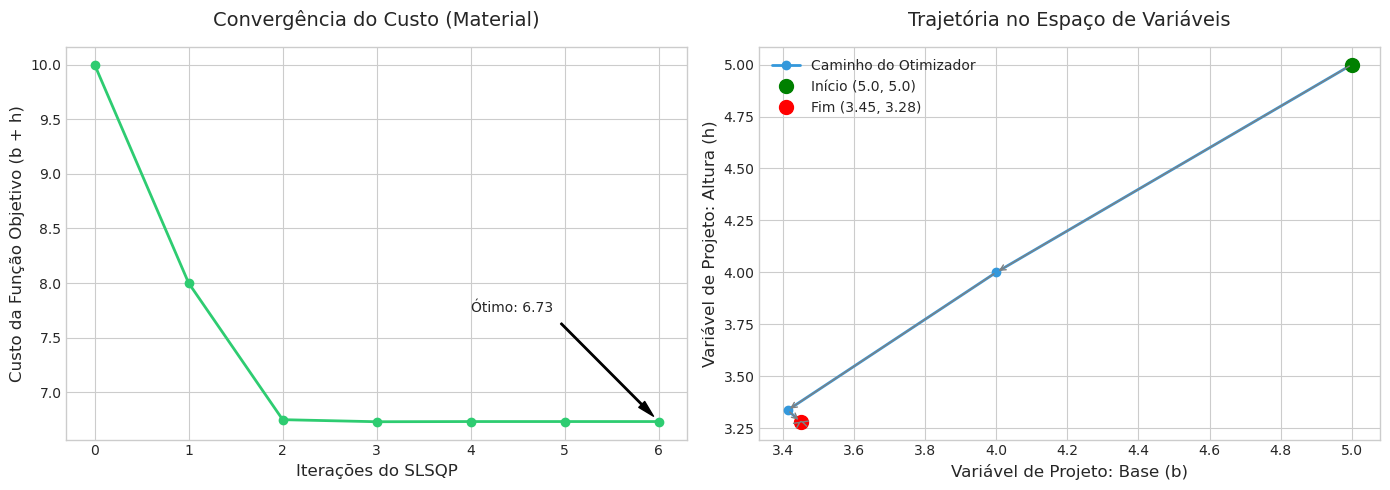

In [48]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import time

# ============================================================================
# PARÂMETROS GERAIS DO PROBLEMA P3
# ============================================================================
beta_T = 3.0
p_fT = norm.cdf(-beta_T)  # Alvo de falha: ~1.3499e-3
std_dev = 0.3
bounds = (0.0, 10.0)
sigma_eps = 0.005 

print("--- INICIANDO OTIMIZAÇÃO WAS COM RASTREAMENTO ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000    
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

g1_base = (B_base**2 * H_base) / 20.0 - 1.0
g2_base = ((B_base + H_base - 5.0)**2 / 30.0) + ((B_base - H_base - 12.0)**2 / 120.0) - 1.0
g3_base = 80.0 / (B_base**2 + 8.0 * H_base + 5.0) - 1.0

If_g1 = norm.cdf(-g1_base / sigma_eps)
If_g2 = norm.cdf(-g2_base / sigma_eps)
If_g3 = norm.cdf(-g3_base / sigma_eps)

# ============================================================================
# FUNÇÕES DE AVALIAÇÃO E RASTREAMENTO
# ============================================================================
def calcular_pf_e_beta(mu, If_valores):
    """Calcula os valores reais de probabilidade e confiabilidade."""
    b, h = mu[0], mu[1]
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    pesos_w = pdf_B * pdf_H
    
    pf_estimado = np.sum(pesos_w * If_valores) / np.sum(pesos_w)
    pf_estimado = max(pf_estimado, 1e-15) 
    beta_estimado = -norm.ppf(pf_estimado)
    
    return pf_estimado, beta_estimado

def avaliar_restricao_continua(mu, If_valores):
    """Retorna o slack de Beta para o otimizador."""
    pf, beta = calcular_pf_e_beta(mu, If_valores)
    return beta - beta_T

def objective_func(mu):
    return mu[0] + mu[1]

# --- RASTREAMENTO DO HISTÓRICO (CALLBACK) ---
historico_b = []
historico_h = []
historico_f = []

def guardar_historico(xk):
    """Esta função é chamada pelo Scipy a cada iteração bem-sucedida."""
    historico_b.append(xk[0])
    historico_h.append(xk[1])
    historico_f.append(objective_func(xk))

# ============================================================================
# OTIMIZAÇÃO (SCIPY SLSQP)
# ============================================================================
cons = [
    {'type': 'ineq', 'fun': lambda mu: avaliar_restricao_continua(mu, If_g1)},
    {'type': 'ineq', 'fun': lambda mu: avaliar_restricao_continua(mu, If_g2)},
    {'type': 'ineq', 'fun': lambda mu: avaliar_restricao_continua(mu, If_g3)}
]

# Chute inicial (e gravando ele como passo 0 no histórico)
mu_0 = np.array([5.0, 5.0])
guardar_historico(mu_0)

print("2. Iniciando busca...")
start_time = time.time()

resp = minimize(objective_func, mu_0, method='SLSQP', bounds=[bounds, bounds], 
                constraints=cons, callback=guardar_historico, options={'eps': 0.1})

end_time = time.time()

# ============================================================================
# RESULTADOS E CÁLCULO FINAL DE CONFIABILIDADE
# ============================================================================
b_opt, h_opt = resp.x

print("\n--- RESULTADOS FINAIS ---")
print(f"Sucesso na Convergência: {resp.success}")
print(f"Média Ótima (b*): {b_opt:.4f}")
print(f"Média Ótima (h*): {h_opt:.4f}")
print(f"Função Objetivo (f): {resp.fun:.4f}")

# Analisando qual restrição "apertou" o projeto
pf1, beta1 = calcular_pf_e_beta(resp.x, If_g1)
pf2, beta2 = calcular_pf_e_beta(resp.x, If_g2)
pf3, beta3 = calcular_pf_e_beta(resp.x, If_g3)

print("\n--- ANÁLISE DE CONFIABILIDADE DO PROJETO ÓTIMO ---")
print(f"Alvo Exigido: Beta >= {beta_T} (Pf <= {p_fT:.2e})")
print(f"Modo de Falha 1 (g1): Beta = {beta1:.4f}  |  Pf = {pf1:.2e}")
print(f"Modo de Falha 2 (g2): Beta = {beta2:.4f}  |  Pf = {pf2:.2e}")
print(f"Modo de Falha 3 (g3): Beta = {beta3:.4f}  |  Pf = {pf3:.2e}")

# ============================================================================
# PLOTAGEM DOS GRÁFICOS
# ============================================================================
print("\n3. Gerando gráficos de convergência...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Convergência do Custo (Função Objetivo)
ax1.plot(range(len(historico_f)), historico_f, marker='o', color='#2ecc71', linewidth=2)
ax1.set_title('Convergência do Custo (Material)', fontsize=14, pad=15)
ax1.set_xlabel('Iterações do SLSQP', fontsize=12)
ax1.set_ylabel('Custo da Função Objetivo (b + h)', fontsize=12)
ax1.annotate(f'Ótimo: {resp.fun:.2f}', 
             xy=(len(historico_f)-1, historico_f[-1]), 
             xytext=(len(historico_f)-3, historico_f[-1] + 1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

# Gráfico 2: Trajetória no Espaço de Projeto (b vs h)
ax2.plot(historico_b, historico_h, marker='o', color='#3498db', linewidth=2, label='Caminho do Otimizador')
ax2.plot(historico_b[0], historico_h[0], 'go', markersize=10, label='Início (5.0, 5.0)')
ax2.plot(historico_b[-1], historico_h[-1], 'ro', markersize=10, label=f'Fim ({b_opt:.2f}, {h_opt:.2f})')

# Adicionando anotações para mostrar a direção do fluxo
for i in range(len(historico_b)-1):
    ax2.annotate('', xy=(historico_b[i+1], historico_h[i+1]), 
                 xytext=(historico_b[i], historico_h[i]),
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax2.set_title('Trajetória no Espaço de Variáveis', fontsize=14, pad=15)
ax2.set_xlabel('Variável de Projeto: Base (b)', fontsize=12)
ax2.set_ylabel('Variável de Projeto: Altura (h)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

Particle swarm

In [46]:
import numpy as np
from scipy.stats import norm
import pyswarms as ps
import time

# ============================================================================
# PARÂMETROS GERAIS DO PROBLEMA P3
# ============================================================================
beta_T = 3.0
p_fT = norm.cdf(-beta_T)  # Alvo de falha: ~1.3499e-3
std_dev = 0.3             # Desvio padrão de B e H
bounds = (0.0, 10.0)      # Limites físicos das médias

epsilon_pf = 1e-4 

# ============================================================================
# PASSO 1: PREPARAÇÃO E AMOSTRAGEM INICIAL (BASE RWAS)
# ============================================================================
print("--- INICIANDO OTIMIZAÇÃO RWAS + PYSWARMS ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000    
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

g1_base = (B_base**2 * H_base) / 20.0 - 1.0
g2_base = ((B_base + H_base - 5.0)**2 / 30.0) + ((B_base - H_base - 12.0)**2 / 120.0) - 1.0
g3_base = 80.0 / (B_base**2 + 8.0 * H_base + 5.0) - 1.0

# ============================================================================
# PASSO 2, 3 e 4: FUNÇÃO RWAS COM ATALHO ATIVADO
# ============================================================================
def avaliar_restricao_rwas(mu, g_valores):
    b, h = mu[0], mu[1]
    
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    
    pesos_w = pdf_B * pdf_H
    soma_total_pesos = np.sum(pesos_w)
    indices_ranqueados = np.argsort(pesos_w)[::-1]
    
    p_fk_acumulado = 0.0
    peso_restante = soma_total_pesos
    
    for idx in indices_ranqueados:
        w_i = pesos_w[idx]
        peso_restante -= w_i 
        
        if g_valores[idx] <= 0:
            p_fk_acumulado += w_i
            
        p_estimado = p_fk_acumulado / soma_total_pesos
        p_limite_superior = (p_fk_acumulado + peso_restante) / soma_total_pesos
        
        # ATALHO DE VOLTA! O PSO não se importa com saltos no gradiente.
        if p_estimado > p_fT:
            return (p_fT - p_estimado) # Negativo (Inviável)
        if p_limite_superior <= p_fT:
            return (p_fT - p_estimado) # Positivo (Viável)
        if (p_limite_superior - p_estimado) <= epsilon_pf:
            return (p_fT - p_estimado) 

    return (p_fT - p_estimado)

# ============================================================================
# CONFIGURANDO O ENXAME DE PARTÍCULAS (MÉTODO DA PENALIDADE)
# ============================================================================
def funcao_custo_enxame(particulas):
    """
    O PySwarms manda um vetor com a posição de TODAS as partículas de uma vez.
    Precisamos avaliar o custo (b + h) de cada uma e aplicar penalidades.
    """
    n_particulas = particulas.shape[0]
    custos = np.zeros(n_particulas)
    
    for i in range(n_particulas):
        mu = particulas[i]
        b, h = mu[0], mu[1]
        
        # Custo real da viga
        custo_material = b + h
        
        # Avaliando as 3 restrições via RWAS
        c1 = avaliar_restricao_rwas(mu, g1_base)
        c2 = avaliar_restricao_rwas(mu, g2_base)
        c3 = avaliar_restricao_rwas(mu, g3_base)
        
        penalidade = 0.0
        fator_mult = 1e6 # Uma parede gigante para o otimizador não cruzar
        
        # Se c1, c2 ou c3 forem negativos, o projeto quebrou! Adicionamos a penalidade.
        if c1 < 0: penalidade += abs(c1) * fator_mult
        if c2 < 0: penalidade += abs(c2) * fator_mult
        if c3 < 0: penalidade += abs(c3) * fator_mult
        
        # O custo final que o PSO enxerga é o material + a penalidade de quebrar
        custos[i] = custo_material + penalidade
        
    return custos

# ============================================================================
# EXECUTANDO A BUSCA PSO
# ============================================================================
print("2. Iniciando busca do ótimo via Particle Swarm Optimization...")
start_time = time.time()

# Limites do espaço de busca [b_min, h_min] e [b_max, h_max]
limites = (np.array([bounds[0], bounds[0]]), np.array([bounds[1], bounds[1]]))

# Hiperparâmetros do enxame
# c1: peso cognitivo (o quanto ela confia nela mesma)
# c2: peso social (o quanto ela segue o grupo)
# w: inércia (o quão rápido ela desacelera)
opcoes = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

# Criando o otimizador Global Best PSO (50 partículas em um espaço de 2 dimensões)
otimizador = ps.single.GlobalBestPSO(n_particles=50, dimensions=2, options=opcoes, bounds=limites)

# Rodando por até 100 iterações (o PySwarms mostrará uma barra de progresso bonita no terminal!)
custo_final, posicao_final = otimizador.optimize(funcao_custo_enxame, iters=100)

end_time = time.time()

# ============================================================================
# RESULTADOS
# ============================================================================
print("\n--- RESULTADOS FINAIS (P3 via RWAS + PSO) ---")
print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Média Ótima (b*): {posicao_final[0]:.4f}")
print(f"Média Ótima (h*): {posicao_final[1]:.4f}")
print(f"Função Objetivo (f): {custo_final:.4f}")
print(f"Gabarito do Livro: b*=3.44, h*=3.29, f=6.73")

2026-05-05 14:42:02,845 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


--- INICIANDO OTIMIZAÇÃO RWAS + PYSWARMS ---
1. Gerando a base de dados estática...
2. Iniciando busca do ótimo via Particle Swarm Optimization...


pyswarms.single.global_best:   0%|          |0/100

pyswarms.single.global_best: 100%|██████████|100/100, best_cost=6.32
2026-05-05 14:44:02,834 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 6.317730129169223, best pos: [2.75512914 3.46974271]



--- RESULTADOS FINAIS (P3 via RWAS + PSO) ---
Tempo de execução: 119.99 segundos
Média Ótima (b*): 2.7551
Média Ótima (h*): 3.4697
Função Objetivo (f): 6.3177
Gabarito do Livro: b*=3.44, h*=3.29, f=6.73


Código suavizado

In [50]:
import numpy as np
from scipy.stats import norm
import pyswarms as ps
import time

# ============================================================================
# PARÂMETROS GERAIS DO PROBLEMA
# ============================================================================
beta_T = 3.0
p_fT = norm.cdf(-beta_T)
std_dev = 0.3
bounds = (0.0, 10.0)

# Parâmetro de suavização (o mesmo do SLSQP)
sigma_eps = 0.005 

print("--- INICIANDO OTIMIZAÇÃO: PSO + INDICADORA CONTÍNUA ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000    
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

g1_base = (B_base**2 * H_base) / 20.0 - 1.0
g2_base = ((B_base + H_base - 5.0)**2 / 30.0) + ((B_base - H_base - 12.0)**2 / 120.0) - 1.0
g3_base = 80.0 / (B_base**2 + 8.0 * H_base + 5.0) - 1.0

# Pré-calculando as indicadoras contínuas (A Rampa)
If_g1 = norm.cdf(-g1_base / sigma_eps)
If_g2 = norm.cdf(-g2_base / sigma_eps)
If_g3 = norm.cdf(-g3_base / sigma_eps)

# ============================================================================
# FUNÇÃO DE AVALIAÇÃO CONTÍNUA (Retorna a folga do Beta)
# ============================================================================
def avaliar_restricao_continua(mu, If_valores):
    b, h = mu[0], mu[1]
    
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    pesos_w = pdf_B * pdf_H
    
    pf_estimado = np.sum(pesos_w * If_valores) / np.sum(pesos_w)
    pf_estimado = max(pf_estimado, 1e-15) 
    
    beta_estimado = -norm.ppf(pf_estimado)
    
    # Se retornar negativo, a viga quebrou (Beta menor que 3.0)
    return beta_estimado - beta_T

# ============================================================================
# FUNÇÃO DE CUSTO DO ENXAME (Com Penalidade Progressiva)
# ============================================================================
def funcao_custo_enxame(particulas):
    n_particulas = particulas.shape[0]
    custos = np.zeros(n_particulas)
    
    for i in range(n_particulas):
        mu = particulas[i]
        custo_material = mu[0] + mu[1]
        
        # Avaliando as folgas (slacks) de Beta
        slack_1 = avaliar_restricao_continua(mu, If_g1)
        slack_2 = avaliar_restricao_continua(mu, If_g2)
        slack_3 = avaliar_restricao_continua(mu, If_g3)
        
        penalidade = 0.0
        # Fator multiplicador da ladeira (um valor alto, mas não infinito)
        peso_penalidade = 1000.0 
        
        # Se o slack for negativo, aplicamos a penalidade proporcional!
        # Quanto mais longe do alvo de segurança, maior a punição.
        if slack_1 < 0: penalidade += abs(slack_1) * peso_penalidade
        if slack_2 < 0: penalidade += abs(slack_2) * peso_penalidade
        if slack_3 < 0: penalidade += abs(slack_3) * peso_penalidade
        
        custos[i] = custo_material + penalidade
        
    return custos

# ============================================================================
# EXECUTANDO A BUSCA PSO
# ============================================================================
print("2. Iniciando busca do ótimo via PSO (com superfície suave)...")
start_time = time.time()

limites = (np.array([bounds[0], bounds[0]]), np.array([bounds[1], bounds[1]]))
opcoes = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

otimizador = ps.single.GlobalBestPSO(n_particles=50, dimensions=2, options=opcoes, bounds=limites)
custo_final, posicao_final = otimizador.optimize(funcao_custo_enxame, iters=100)

end_time = time.time()

print("\n--- RESULTADOS FINAIS (PSO Suavizado) ---")
print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Média Ótima (b*): {posicao_final[0]:.4f}")
print(f"Média Ótima (h*): {posicao_final[1]:.4f}")
print(f"Custo do Projeto (b+h): {posicao_final[0] + posicao_final[1]:.4f}")

2026-05-05 15:08:10,406 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


--- INICIANDO OTIMIZAÇÃO: PSO + INDICADORA CONTÍNUA ---
1. Gerando a base de dados estática...
2. Iniciando busca do ótimo via PSO (com superfície suave)...


pyswarms.single.global_best: 100%|██████████|100/100, best_cost=6.73
2026-05-05 15:09:20,290 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 6.73274059396541, best pos: [3.45072343 3.28201716]



--- RESULTADOS FINAIS (PSO Suavizado) ---
Tempo de execução: 69.89 segundos
Média Ótima (b*): 3.4507
Média Ótima (h*): 3.2820
Custo do Projeto (b+h): 6.7327


2026-05-05 16:10:44,812 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


--- INICIANDO OTIMIZAÇÃO: PSO + INDICADORA CONTÍNUA ---
1. Gerando a base de dados estática...
2. Iniciando busca do ótimo via PSO...


pyswarms.single.global_best: 100%|██████████|100/100, best_cost=6.73
2026-05-05 16:11:49,956 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 6.733370552566439, best pos: [3.45044979 3.28292077]



--- RESULTADOS FINAIS ---
Tempo de execução: 65.15 segundos
Média Ótima (b*): 3.4504
Média Ótima (h*): 3.2829
Custo (b+h): 6.7334

3. Gerando gráficos do Enxame...


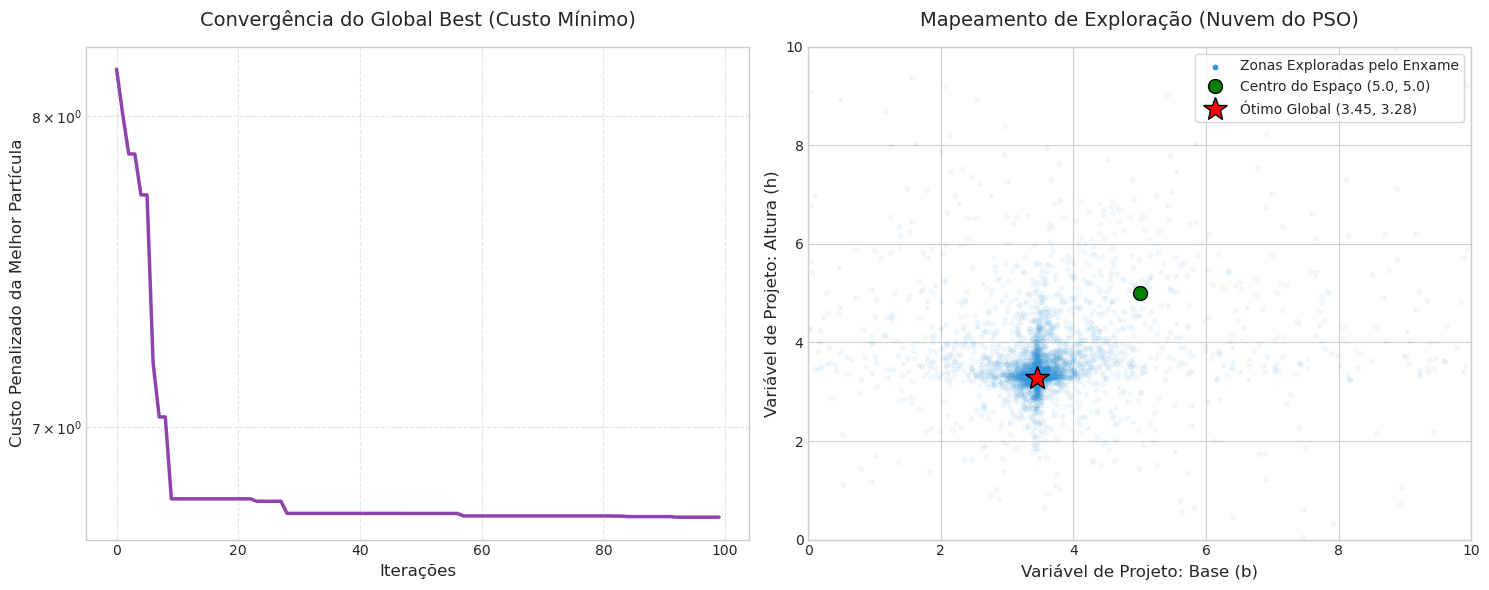

In [ ]:
import numpy as np
from scipy.stats import norm
import pyswarms as ps
import matplotlib.pyplot as plt
import time

# ============================================================================
# PARÂMETROS GERAIS DO PROBLEMA
# ============================================================================
beta_T = 3.0
p_fT = norm.cdf(-beta_T)
std_dev = 0.3
bounds = (0.0, 10.0)
sigma_eps = 0.005

print("--- INICIANDO OTIMIZAÇÃO: PSO + INDICADORA CONTÍNUA ---")
print("1. Gerando a base de dados estática...")

N_samples = 100000    
margem = 4.0 * std_dev
limite_inferior = bounds[0] - margem
limite_superior = bounds[1] + margem

np.random.seed(42) 
B_base = np.random.uniform(limite_inferior, limite_superior, N_samples)
H_base = np.random.uniform(limite_inferior, limite_superior, N_samples)

g1_base = (B_base**2 * H_base) / 20.0 - 1.0
g2_base = ((B_base + H_base - 5.0)**2 / 30.0) + ((B_base - H_base - 12.0)**2 / 120.0) - 1.0
g3_base = 80.0 / (B_base**2 + 8.0 * H_base + 5.0) - 1.0

If_g1 = norm.cdf(-g1_base / sigma_eps)
If_g2 = norm.cdf(-g2_base / sigma_eps)
If_g3 = norm.cdf(-g3_base / sigma_eps)

# ============================================================================
# FUNÇÃO DE AVALIAÇÃO CONTÍNUA
# ============================================================================
def avaliar_restricao_continua(mu, If_valores):
    b, h = mu[0], mu[1]
    
    pdf_B = norm.pdf(B_base, loc=b, scale=std_dev)
    pdf_H = norm.pdf(H_base, loc=h, scale=std_dev)
    pesos_w = pdf_B * pdf_H
    
    pf_estimado = np.sum(pesos_w * If_valores) / np.sum(pesos_w)
    pf_estimado = max(pf_estimado, 1e-15) 
    
    beta_estimado = -norm.ppf(pf_estimado)
    return beta_estimado - beta_T

# ============================================================================
# FUNÇÃO DE CUSTO DO ENXAME
# ============================================================================
def funcao_custo_enxame(particulas):
    n_particulas = particulas.shape[0]
    custos = np.zeros(n_particulas)
    
    for i in range(n_particulas):
        mu = particulas[i]
        custo_material = mu[0] + mu[1]
        
        slack_1 = avaliar_restricao_continua(mu, If_g1)
        slack_2 = avaliar_restricao_continua(mu, If_g2)
        slack_3 = avaliar_restricao_continua(mu, If_g3)
        
        penalidade = 0.0
        peso_penalidade = 1000.0 
        
        if slack_1 < 0: penalidade += abs(slack_1) * peso_penalidade
        if slack_2 < 0: penalidade += abs(slack_2) * peso_penalidade
        if slack_3 < 0: penalidade += abs(slack_3) * peso_penalidade
        
        custos[i] = custo_material + penalidade
        
    return custos

# ============================================================================
# EXECUTANDO A BUSCA PSO
# ============================================================================
print("2. Iniciando busca do ótimo via PSO...")
start_time = time.time()

limites = (np.array([bounds[0], bounds[0]]), np.array([bounds[1], bounds[1]]))
opcoes = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

otimizador = ps.single.GlobalBestPSO(n_particles=50, dimensions=2, options=opcoes, bounds=limites)
custo_final, posicao_final = otimizador.optimize(funcao_custo_enxame, iters=100)

end_time = time.time()

# ============================================================================
# RESULTADOS NO TERMINAL
# ============================================================================
print("\n--- RESULTADOS FINAIS ---")
print(f"Tempo de execução: {end_time - start_time:.2f} segundos")
print(f"Média Ótima (b*): {posicao_final[0]:.4f}")
print(f"Média Ótima (h*): {posicao_final[1]:.4f}")
print(f"Custo (b+h): {posicao_final[0] + posicao_final[1]:.4f}")

# ============================================================================
# PLOTAGEM DOS GRÁFICOS (O QUE É MAIS INTERESSANTE NO PSO)
# ============================================================================
print("\n3. Gerando gráficos do Enxame...")

# Extraindo o histórico do PySwarms
historico_custo = otimizador.cost_history
# pos_history é um array 3D: (iteracoes, particulas, dimensões)
historico_posicoes = np.array(otimizador.pos_history)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- GRÁFICO 1: Convergência do Enxame ---
ax1.plot(historico_custo, color='#8e44ad', linewidth=2.5)
ax1.set_title('Convergência do Global Best (Custo Mínimo)', fontsize=14, pad=15)
ax1.set_xlabel('Iterações', fontsize=12)
ax1.set_ylabel('Custo Penalizado da Melhor Partícula', fontsize=12)
ax1.set_yscale('log') # Escala Log ajuda muito a ver a queda inicial da penalidade
ax1.grid(True, which="both", ls="--", alpha=0.5)

# --- GRÁFICO 2: Nuvem de Exploração (Scatter Plot) ---
# Extraindo as coordenadas x (b) e y (h) de TODAS as partículas em TODAS as iterações
todas_b = historico_posicoes[:, :, 0].flatten()
todas_h = historico_posicoes[:, :, 1].flatten()

# Plotando a "nuvem" de lugares que os pássaros visitaram (com transparência)
ax2.scatter(todas_b, todas_h, color='#3498db', alpha=0.05, s=10, label='Zonas Exploradas pelo Enxame')

# Marcando o ponto inicial do espaço
ax2.plot(5.0, 5.0, 'go', markersize=10, markeredgecolor='black', label='Centro do Espaço (5.0, 5.0)')

# Marcando o ponto Ótimo Final encontrado
ax2.plot(posicao_final[0], posicao_final[1], 'r*', markersize=18, markeredgecolor='black', label=f'Ótimo Global ({posicao_final[0]:.2f}, {posicao_final[1]:.2f})')

ax2.set_title('Mapeamento de Exploração (Nuvem do PSO)', fontsize=14, pad=15)
ax2.set_xlabel('Variável de Projeto: Base (b)', fontsize=12)
ax2.set_ylabel('Variável de Projeto: Altura (h)', fontsize=12)
ax2.set_xlim(bounds[0], bounds[1])
ax2.set_ylim(bounds[0], bounds[1])

# Para o gráfico 2, vamos arrumar a legenda para ela não sumir na nuvem
legend = ax2.legend(loc='upper right', frameon=True)
for lh in legend.legend_handles: 
    lh.set_alpha(1) # Faz a bolinha azul da legenda ficar sólida

plt.tight_layout()
plt.show()